<a href="https://colab.research.google.com/github/Sairakesh08/Ensuring-Skin-Cancer/blob/main/model_Buliding_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q keras-tuner
!pip install opencv-python
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.7 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
import tensorflow as tf
from PIL import Image
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB0, VGG16
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Conv2D, MaxPooling2D, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import warnings
from google.colab import drive
import seaborn as sns
import matplotlib.patches as patches
from google.colab import files
from tensorflow.keras.preprocessing import image
warnings.filterwarnings('ignore')

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset_path = "/content/drive/MyDrive/dataset_binary_balanced_undersampled"

In [5]:
dataset_path = "/content/drive/MyDrive/dataset_binary_balanced_undersampled"

classes = os.listdir(dataset_path)
print("Classes:", classes)

class_counts = {}
for cls in classes:
    class_dir = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(class_dir))

print("\nImage counts per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

Classes: ['benign', 'malignant']

Image counts per class:
benign: 9340 images
malignant: 9340 images


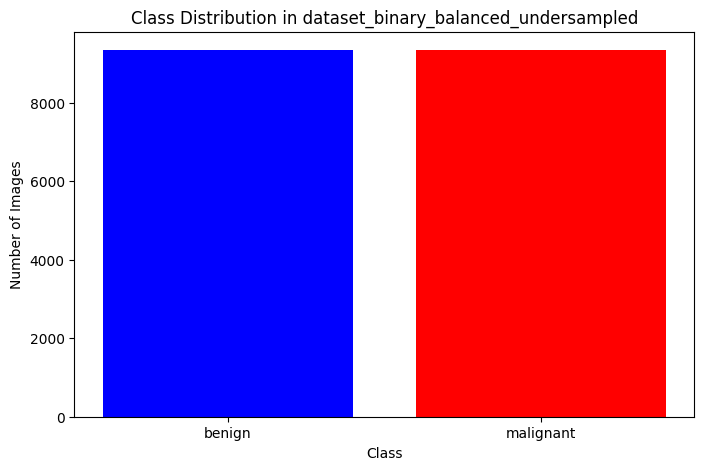

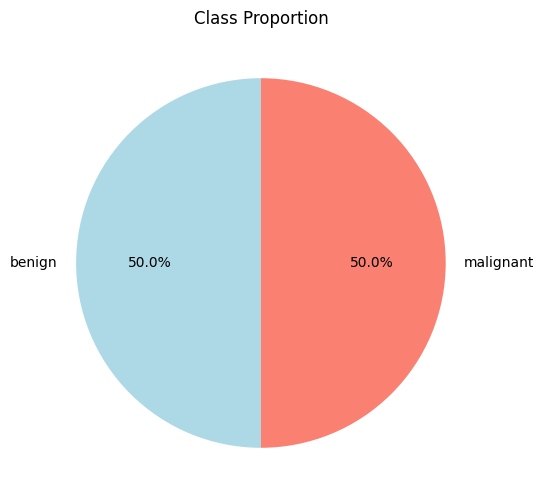

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'red'])
plt.title("Class Distribution in dataset_binary_balanced_undersampled")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

plt.figure(figsize=(6, 6))
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%',
        colors=['lightblue', 'salmon'], startangle=90)
plt.title("Class Proportion")
plt.show()

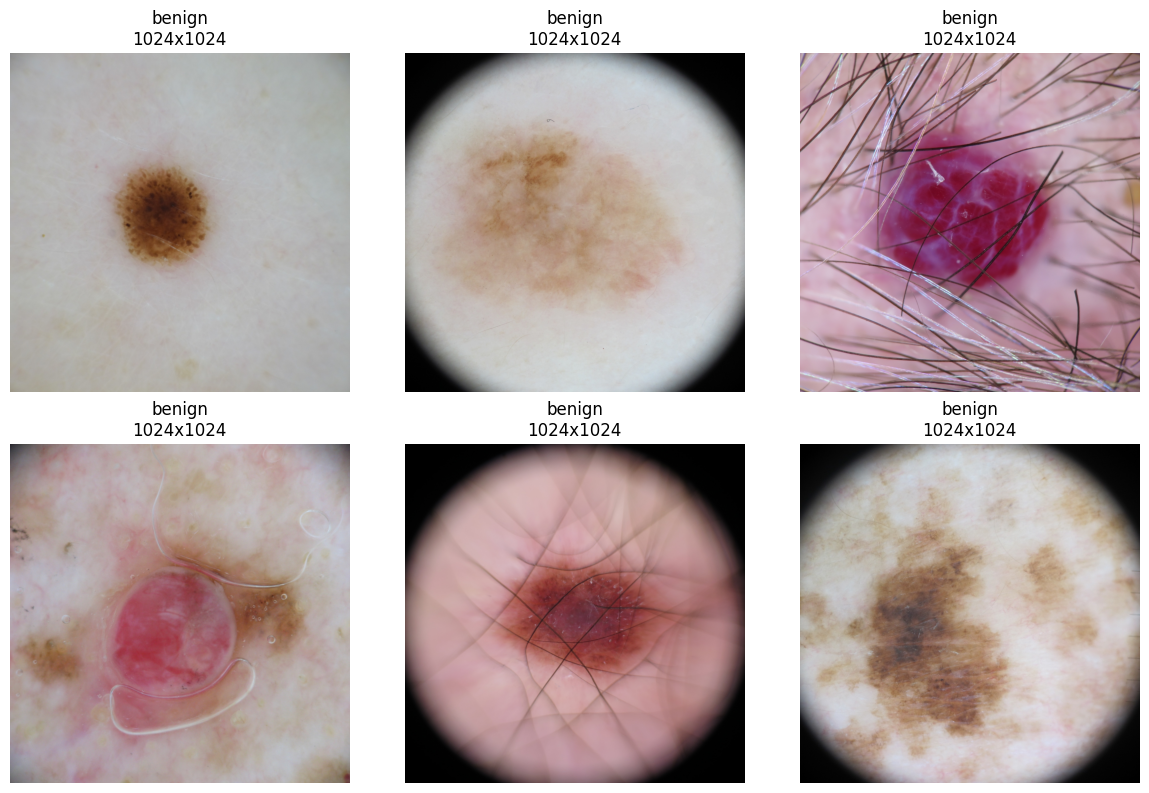

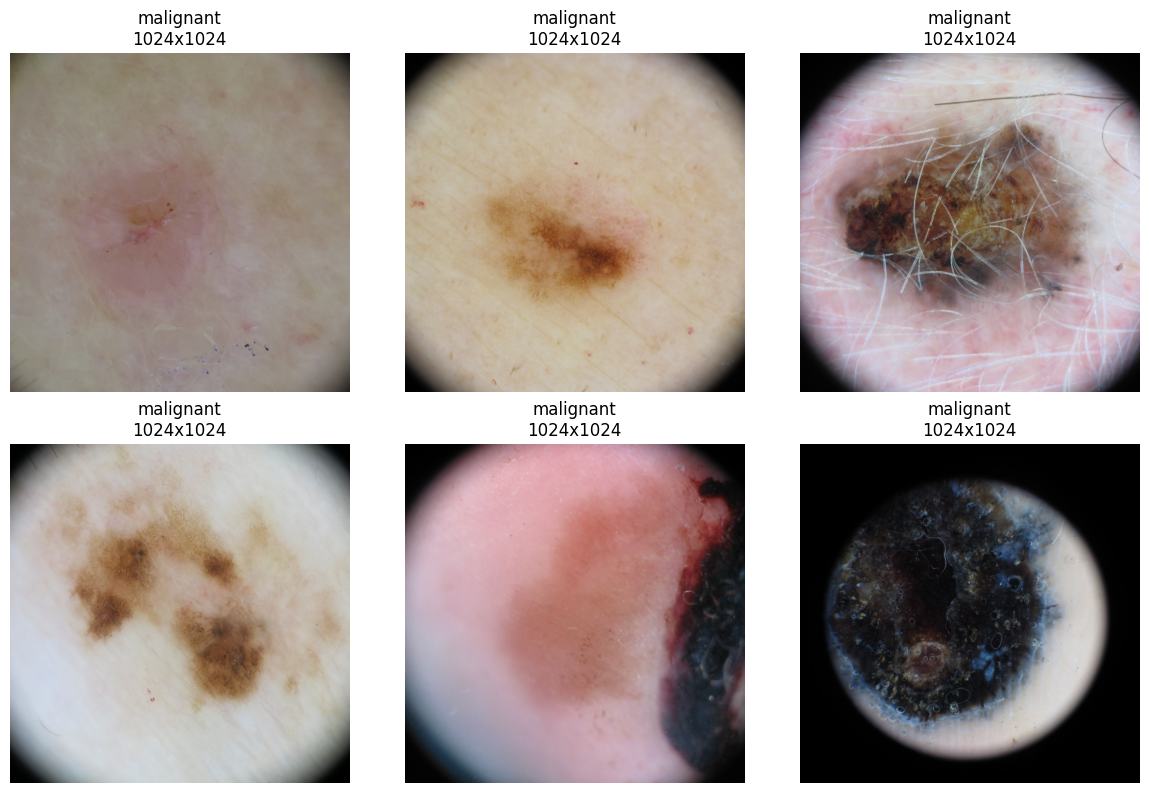

In [7]:
def plot_samples(class_name, num_samples=6):
    class_dir = os.path.join(dataset_path, class_name)
    images = os.listdir(class_dir)[:num_samples]

    plt.figure(figsize=(12, 8))
    for i, img_name in enumerate(images):
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path)

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"{class_name}\n{img.size[0]}x{img.size[1]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display samples
plot_samples("benign")
plot_samples("malignant")

In [8]:
dataset_path = "/content/drive/MyDrive/dataset_binary_balanced_undersampled"
npy_save_path = os.path.join(dataset_path, "npy_files")
os.makedirs(npy_save_path, exist_ok=True)

raw_path = os.path.join(npy_save_path, "images_raw.npy")
cleaned_path = os.path.join(npy_save_path, "images_cleaned.npy")
labels_path = os.path.join(npy_save_path, "labels.npy")

def remove_hair(img_array):
    grayscale = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(1, (17, 17))
    blackhat = cv2.morphologyEx(grayscale, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    inpainted = cv2.inpaint(img_array, mask, 1, cv2.INPAINT_TELEA)
    return inpainted

if os.path.exists(raw_path) and os.path.exists(cleaned_path) and os.path.exists(labels_path):
    print("NPY files found. Skipping preprocessing...")
    images_raw = np.load(raw_path)
    images_cleaned = np.load(cleaned_path)
    labels = np.load(labels_path)
else:
    print("NPY files not found. Running hair removal and preprocessing...")

    IMAGE_SIZE = (224, 224)
    images_raw = []
    images_cleaned = []
    labels = []

    classes = os.listdir(dataset_path)
    classes = [cls for cls in classes if os.path.isdir(os.path.join(dataset_path, cls))]  # skip npy_files folder

    for label, class_name in enumerate(classes):
        class_dir = os.path.join(dataset_path, class_name)
        image_files = os.listdir(class_dir)

        for img_name in tqdm(image_files):
            img_path = os.path.join(class_dir, img_name)
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize(IMAGE_SIZE)
                img_array = np.array(img)

                images_raw.append(img_array)
                images_cleaned.append(remove_hair(img_array))
                labels.append(label)
            except Exception as e:
                print(f"Skipped {img_path}: {e}")

    images_raw = np.array(images_raw)
    images_cleaned = np.array(images_cleaned)
    labels = np.array(labels)

    np.save(raw_path, images_raw)
    np.save(cleaned_path, images_cleaned)
    np.save(labels_path, labels)
    print("NPY files saved!")


NPY files not found. Running hair removal and preprocessing...


100%|██████████| 9340/9340 [09:43<00:00, 16.00it/s]
0it [00:00, ?it/s]


NPY files saved!


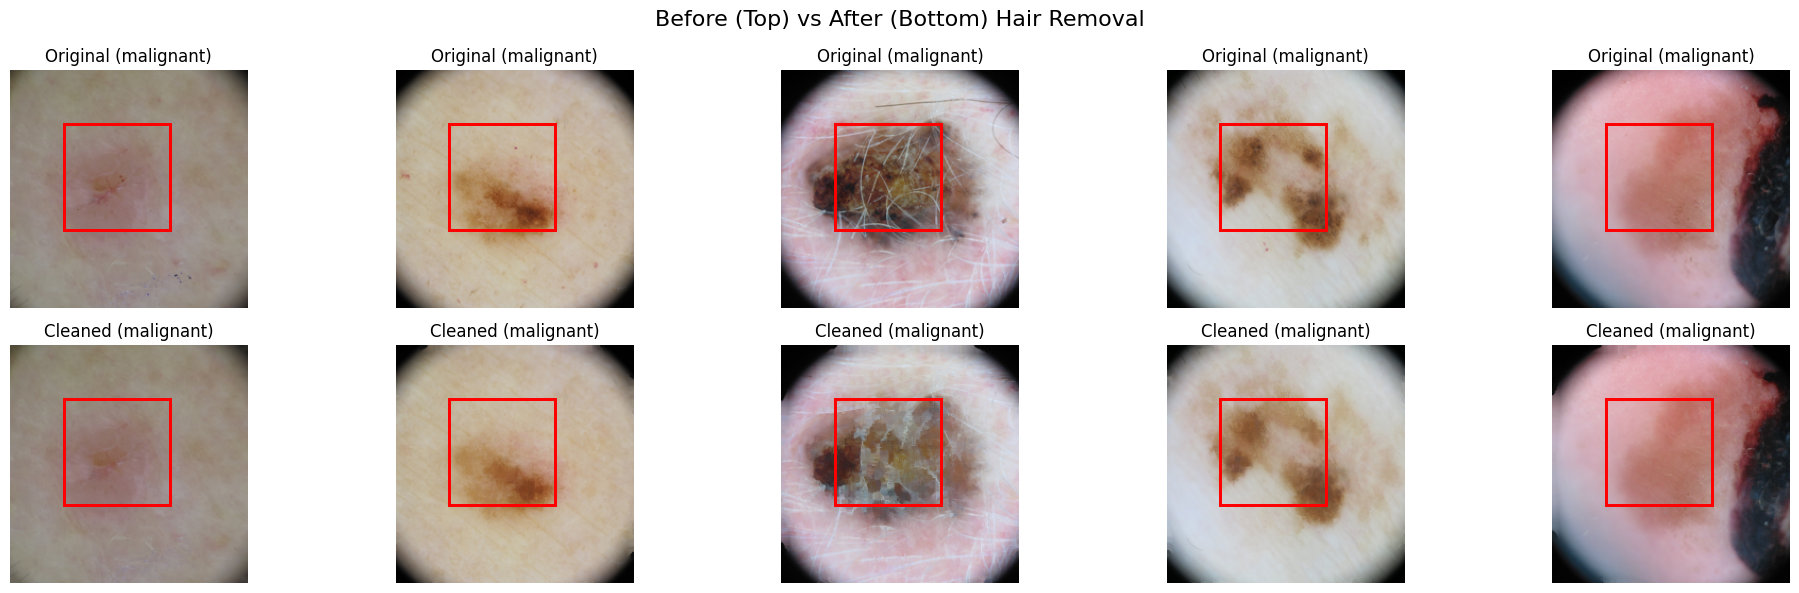

In [9]:
def show_sample_images_with_highlight(images_raw, images_cleaned, labels, class_names=["benign", "malignant"], num_images=5):
    fig, axs = plt.subplots(2, num_images, figsize=(20, 6))
    fig.suptitle("Before (Top) vs After (Bottom) Hair Removal", fontsize=16)

    for class_label in [0, 1]:
        class_indices = np.where(labels == class_label)[0][:num_images]

        for i, idx in enumerate(class_indices):
            axs[0, i].imshow(images_raw[idx])
            axs[0, i].set_title(f"Original ({class_names[class_label]})")
            axs[0, i].axis('off')

            axs[1, i].imshow(images_cleaned[idx])
            axs[1, i].set_title(f"Cleaned ({class_names[class_label]})")
            axs[1, i].axis('off')

            rect1 = patches.Rectangle((50, 50), 100, 100, linewidth=2, edgecolor='r', facecolor='none')
            rect2 = patches.Rectangle((50, 50), 100, 100, linewidth=2, edgecolor='r', facecolor='none')
            axs[0, i].add_patch(rect1)
            axs[1, i].add_patch(rect2)

    plt.tight_layout()
    plt.show()

show_sample_images_with_highlight(images_raw, images_cleaned, labels)

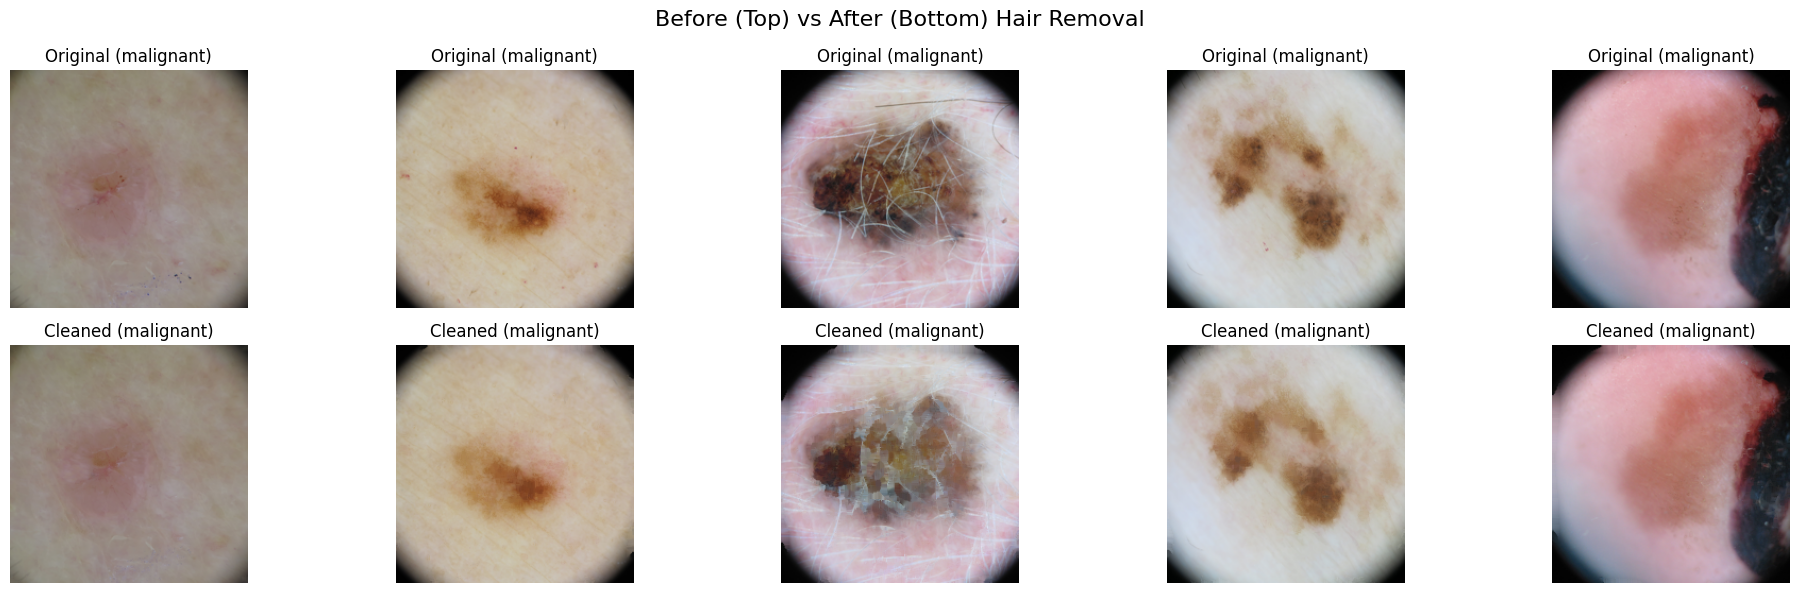

In [10]:
def show_sample_images(images_raw, images_cleaned, labels, class_names=["benign", "malignant"], num_images=5):
    fig, axs = plt.subplots(2, num_images, figsize=(20, 6))
    fig.suptitle("Before (Top) vs After (Bottom) Hair Removal", fontsize=16)

    for class_label in [0, 1]:
        class_indices = np.where(labels == class_label)[0][:num_images]

        for i, idx in enumerate(class_indices):
            axs[0, i].imshow(images_raw[idx])
            axs[0, i].set_title(f"Original ({class_names[class_label]})")
            axs[0, i].axis('off')

            axs[1, i].imshow(images_cleaned[idx])
            axs[1, i].set_title(f"Cleaned ({class_names[class_label]})")
            axs[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Display samples
show_sample_images(images_raw, images_cleaned, labels)


In [11]:
from sklearn.model_selection import train_test_split

images_cleaned = images_cleaned / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    images_cleaned, labels, test_size=0.2, stratify=labels, random_state=42
)

print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")


Training samples: 14944, Validation samples: 3736


# CNN Model

In [12]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Class weights

In [13]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), class_weights_array))
print("Class Weights:", class_weights)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)


Class Weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}
Epoch 1/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 208s 442ms/step - accuracy: 0.6286 - loss: 0.6285 - val_accuracy: 0.7016 - val_loss: 0.5571
Epoch 2/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 196s 420ms/step - accuracy: 0.7057 - loss: 0.5465 - val_accuracy: 0.6911 - val_loss: 0.5563
Epoch 3/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 196s 419ms/step - accuracy: 0.7118 - loss: 0.5398 - val_accuracy: 0.7112 - val_loss: 0.5415
Epoch 4/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 198s 424ms/step - accuracy: 0.7272 - loss: 0.5289 - val_accuracy: 0.7171 - val_loss: 0.5413
Epoch 5/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 197s 422ms/step - accuracy: 0.7269 - loss: 0.5244 - val_accuracy: 0.7254 - val_loss: 0.5268
Epoch 6/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 198s 423ms/step - accuracy: 0.7356 - loss: 0.5148 - val_accuracy: 0.7272 - val_loss: 0.5282
Epoch 7/30
467/467 ━━━━━━━━━━━━━━━━━━━━ 198s 424ms/step - accuracy: 0.7403 - loss: 0.5119 - val_accuracy: 0.7350 - val_loss: 0.5189


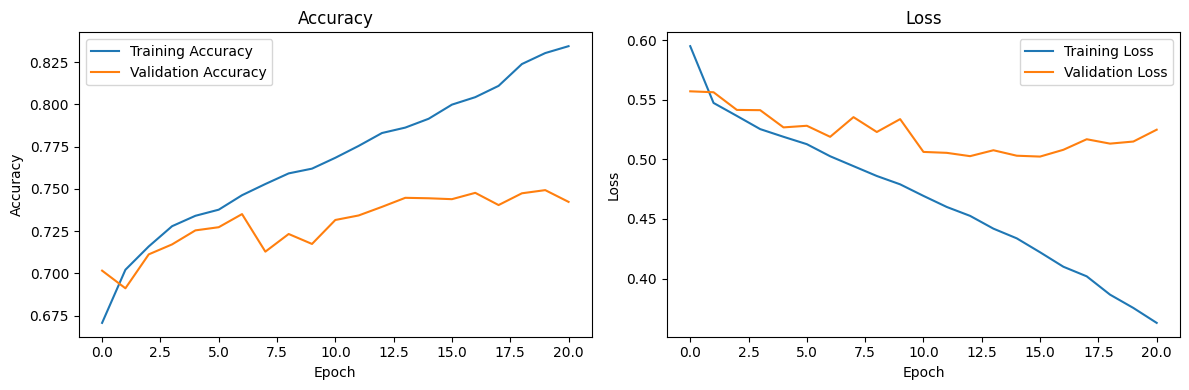

In [14]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()


117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step
Classification Report:
              precision    recall  f1-score   support

      benign       0.75      0.72      0.74      1868
   malignant       0.73      0.76      0.75      1868

    accuracy                           0.74      3736
   macro avg       0.74      0.74      0.74      3736
weighted avg       0.74      0.74      0.74      3736

Confusion Matrix:
[[1351  517]
 [ 440 1428]]
ROC-AUC Score: 0.8330


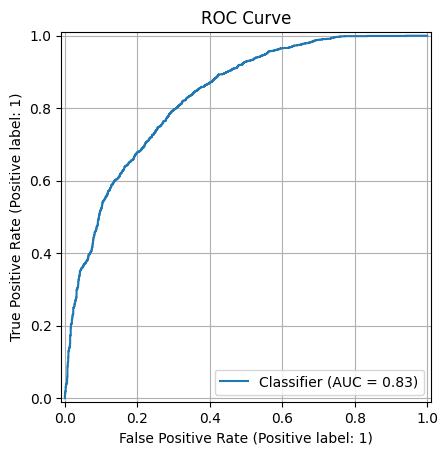

In [15]:
# Predict on validation set
y_pred_prob = cnn_model.predict(X_val).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["benign", "malignant"]))

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_val, y_pred)
print(cm)

# ROC-AUC
roc_auc = roc_auc_score(y_val, y_pred_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC curve
RocCurveDisplay.from_predictions(y_val, y_pred_prob)
plt.title("ROC Curve")
plt.grid(True)
plt.show()


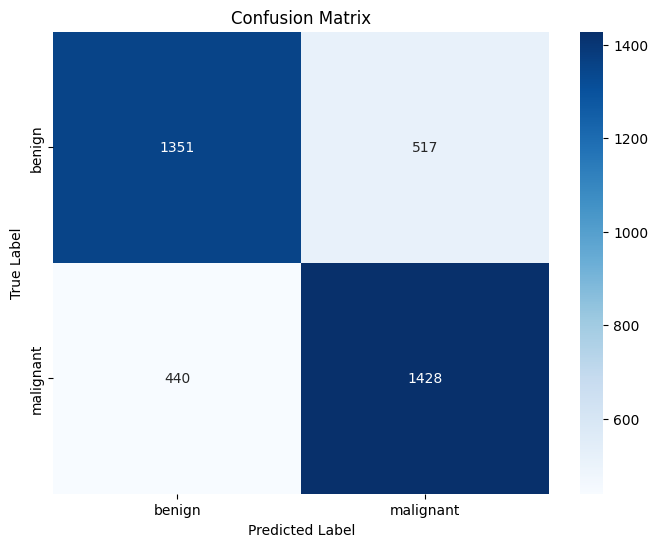

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# Save the model

In [17]:
model_save_path = "/content/drive/MyDrive/dataset_binary_balanced_undersampled/cnn_model.keras"
cnn_model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to /content/drive/MyDrive/dataset_binary_balanced_undersampled/cnn_model.keras


In [18]:
from tensorflow.keras.models import load_model
loaded_model = load_model("/content/drive/MyDrive/dataset_binary_balanced_undersampled/cnn_model.keras")

# Evaluate the model and print test loss and accuracy


In [19]:
loss, accuracy = cnn_model.evaluate(X_val, y_val, verbose=0)
print(f"CNN Model - Validation Loss: {loss:.4f}")
print(f"CNN Model - Validation Accuracy: {accuracy:.4f}")

CNN Model - Validation Loss: 0.5023
CNN Model - Validation Accuracy: 0.7438


#ResNet Model

In [20]:
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

resnet_model.compile(optimizer=Adam(learning_rate=1e-4),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

resnet_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [21]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), class_weights_array))
print("Class Weights:", class_weights)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Class Weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


In [23]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_resnet = resnet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 254s 544ms/step - accuracy: 0.6662 - loss: 0.6099 - val_accuracy: 0.6555 - val_loss: 0.6086
Epoch 2/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 253s 542ms/step - accuracy: 0.6761 - loss: 0.6051 - val_accuracy: 0.6834 - val_loss: 0.6034
Epoch 3/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 254s 543ms/step - accuracy: 0.6755 - loss: 0.6095 - val_accuracy: 0.6734 - val_loss: 0.6010
Epoch 4/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 255s 546ms/step - accuracy: 0.6787 - loss: 0.6046 - val_accuracy: 0.6804 - val_loss: 0.6000
Epoch 5/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 255s 545ms/step - accuracy: 0.6715 - loss: 0.6037 - val_accuracy: 0.6555 - val_loss: 0.6046
Epoch 6/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 258s 552ms/step - accuracy: 0.6683 - loss: 0.6078 - val_accuracy: 0.6451 - val_loss: 0.6074
Epoch 7/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 256s 549ms/step - accuracy: 0.6777 - loss: 0.6043 - val_accuracy: 0.6555 - val_loss: 0.6021
Epoch 8/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 255s 545ms/step - accuracy: 0.6735 -

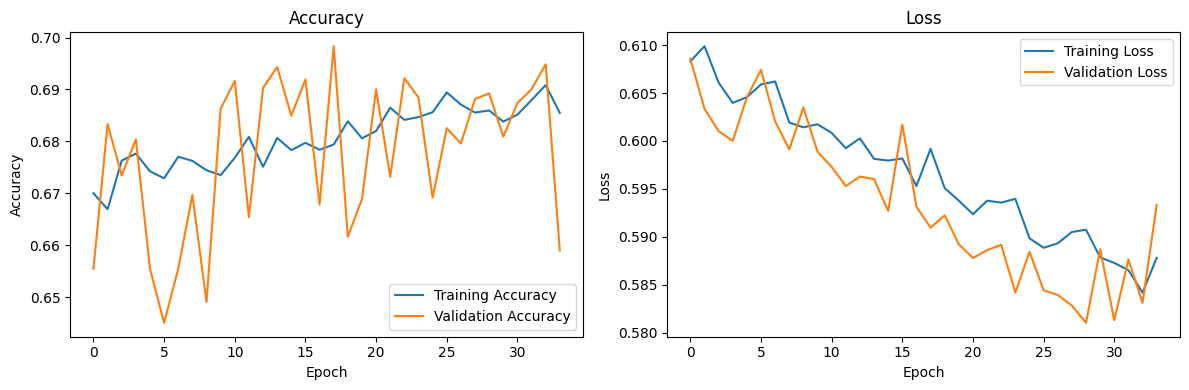

In [24]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()

117/117 ━━━━━━━━━━━━━━━━━━━━ 59s 472ms/step
Classification Report - ResNet50:
              precision    recall  f1-score   support

      benign       0.67      0.73      0.70      1868
   malignant       0.71      0.65      0.68      1868

    accuracy                           0.69      3736
   macro avg       0.69      0.69      0.69      3736
weighted avg       0.69      0.69      0.69      3736

Confusion Matrix:
[[1364  504]
 [ 657 1211]]
ROC-AUC Score: 0.7660


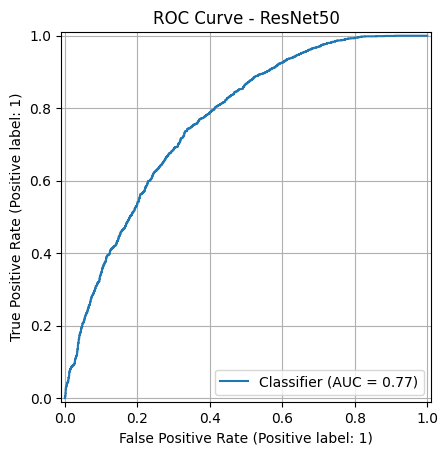

In [25]:
y_pred_resnet_prob = resnet_model.predict(X_val).ravel()
y_pred_resnet = (y_pred_resnet_prob > 0.5).astype(int)

print("Classification Report - ResNet50:")
print(classification_report(y_val, y_pred_resnet, target_names=["benign", "malignant"]))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_resnet))

resnet_auc = roc_auc_score(y_val, y_pred_resnet_prob)
print(f"ROC-AUC Score: {resnet_auc:.4f}")

RocCurveDisplay.from_predictions(y_val, y_pred_resnet_prob)
plt.title("ROC Curve - ResNet50")
plt.grid(True)
plt.show()


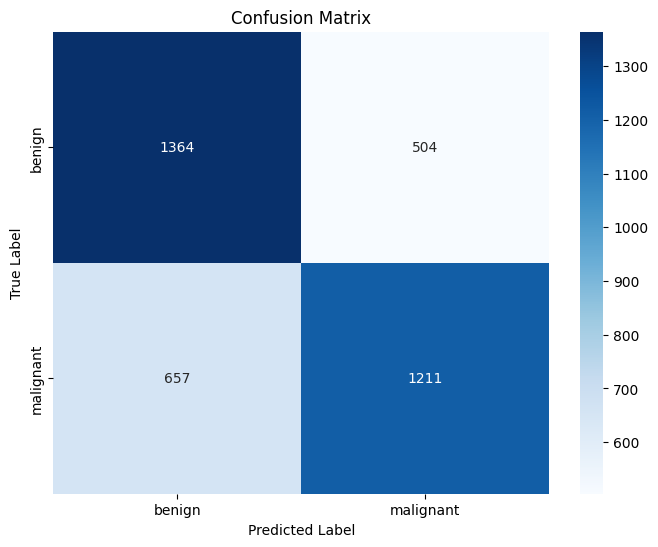

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_resnet)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [27]:
model_save_path = "/content/drive/MyDrive/dataset_binary_balanced_undersampled/resnet_model.keras"
resnet_model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to /content/drive/MyDrive/dataset_binary_balanced_undersampled/resnet_model.keras


In [28]:
loss, accuracy = resnet_model.evaluate(X_val, y_val, verbose=0)
print(f"ResNet Model - Validation Loss: {loss:.4f}")
print(f"ResNet Model - Validation Accuracy: {accuracy:.4f}")

ResNet Model - Validation Loss: 0.5810
ResNet Model - Validation Accuracy: 0.6892


# ResNet50 Fine-tune

In [29]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Fine-tune
history_finetuned = resnet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)
resnet_model.save('/content/drive/MyDrive/dataset_binary_balanced_undersampled/fine_tuned_resnet50_skin_cancer.keras')
print("Fine-tuned ResNet50 model saved to Drive.")

Epoch 1/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 429s 890ms/step - accuracy: 0.6165 - loss: 0.7349 - val_accuracy: 0.7088 - val_loss: 0.5851
Epoch 2/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 407s 871ms/step - accuracy: 0.7141 - loss: 0.5651 - val_accuracy: 0.6783 - val_loss: 0.5871
Epoch 3/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 405s 866ms/step - accuracy: 0.7290 - loss: 0.5410 - val_accuracy: 0.7080 - val_loss: 0.5548
Epoch 4/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 406s 868ms/step - accuracy: 0.7243 - loss: 0.5378 - val_accuracy: 0.6635 - val_loss: 0.5965
Epoch 5/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 405s 867ms/step - accuracy: 0.7360 - loss: 0.5236 - val_accuracy: 0.7184 - val_loss: 0.5539
Epoch 6/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 406s 869ms/step - accuracy: 0.7425 - loss: 0.5209 - val_accuracy: 0.6799 - val_loss: 0.6581
Epoch 7/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 405s 867ms/step - accuracy: 0.7407 - loss: 0.5270 - val_accuracy: 0.7256 - val_loss: 0.5309
Epoch 8/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 407s 871ms/step - accuracy: 0.7489 -

In [30]:
# Evaluate the model
loss, accuracy = resnet_model.evaluate(X_val, y_val, verbose=0)
print(f"FineTune_ResNet Model - Validation Loss: {loss:.4f}")
print(f"FineTune_ResNet Model - Validation Accuracy: {accuracy:.4f}")

FineTune_ResNet Model - Validation Loss: 0.5281
FineTune_ResNet Model - Validation Accuracy: 0.7363


117/117 ━━━━━━━━━━━━━━━━━━━━ 59s 473ms/step
Classification Report - ResNet50 (Fine-Tuned):
              precision    recall  f1-score   support

      benign       0.70      0.82      0.76      1868
   malignant       0.78      0.65      0.71      1868

    accuracy                           0.74      3736
   macro avg       0.74      0.74      0.73      3736
weighted avg       0.74      0.74      0.73      3736

Confusion Matrix:
[[1530  338]
 [ 647 1221]]
ROC-AUC Score (Fine-Tuned): 0.8239


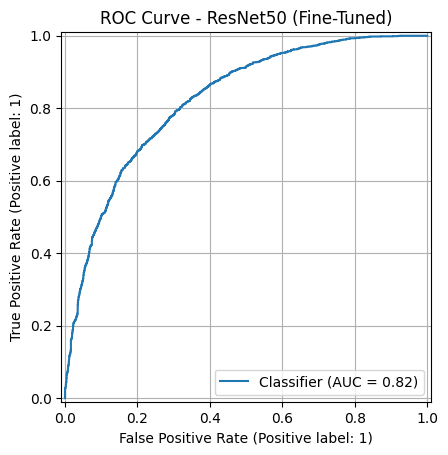

In [31]:
y_pred_ft_prob = resnet_model.predict(X_val).ravel()
y_pred_ft = (y_pred_ft_prob > 0.5).astype(int)

print("Classification Report - ResNet50 (Fine-Tuned):")
print(classification_report(y_val, y_pred_ft, target_names=["benign", "malignant"]))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_ft))

ft_auc = roc_auc_score(y_val, y_pred_ft_prob)
print(f"ROC-AUC Score (Fine-Tuned): {ft_auc:.4f}")

RocCurveDisplay.from_predictions(y_val, y_pred_ft_prob)
plt.title("ROC Curve - ResNet50 (Fine-Tuned)")
plt.grid(True)
plt.show()


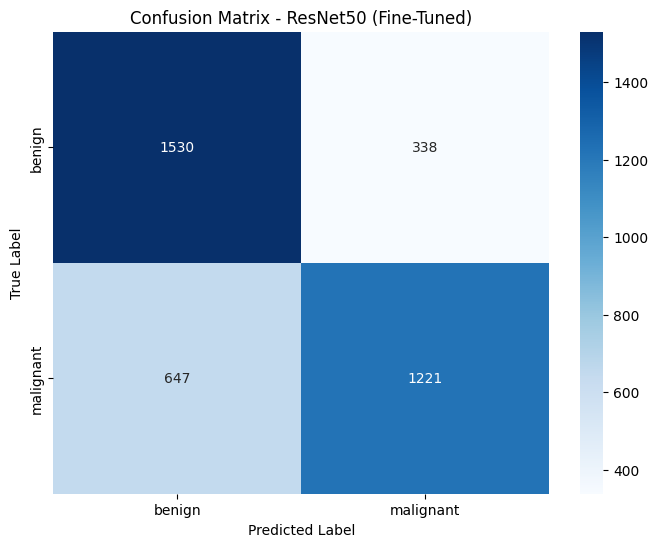

In [32]:
cm = confusion_matrix(y_val, y_pred_ft)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.title("Confusion Matrix - ResNet50 (Fine-Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# EfficientNetB0 model


In [33]:
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
base_model_eff.trainable = False

# 2. Add new classification head
x = base_model_eff.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

# 3. Create the model
eff_model = Model(inputs=base_model_eff.input, outputs=output)

# 4. Compile
eff_model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# 5. Show model summary
eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [34]:
# 6. Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), class_weights_array))

# 7. Set early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 8. Train the model
history_eff = eff_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# 9. Save model
model_save_path_eff = '/content/drive/MyDrive/dataset_binary_balanced_undersampled/efficientnetb0_model.keras'
eff_model.save(model_save_path_eff)
print(f"EfficientNetB0 model saved at: {model_save_path_eff}")


Epoch 1/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 218s 449ms/step - accuracy: 0.5061 - loss: 0.6974 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 203s 434ms/step - accuracy: 0.4963 - loss: 0.6941 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 202s 433ms/step - accuracy: 0.5031 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 201s 430ms/step - accuracy: 0.5066 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 202s 432ms/step - accuracy: 0.4935 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 207s 443ms/step - accuracy: 0.4931 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 199s 425ms/step - accuracy: 0.5039 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 199s 425ms/step - accuracy: 0.5081 -

In [35]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

eff_model = Model(inputs=base_model.input, outputs=output)


base_model.trainable = True

fine_tune_at = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Frozen layers: {fine_tune_at}, Trainable layers: {len(base_model.layers) - fine_tune_at}")

eff_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_eff_ft = eff_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

fine_tuned_model_path = '/content/drive/MyDrive/dataset_binary_balanced_undersampled/efficientnetb0_finetuned_model.keras'
eff_model.save(fine_tuned_model_path)
print(f"Fine-tuned EfficientNetB0 model saved at: {fine_tuned_model_path}")

Frozen layers: 188, Trainable layers: 50
Epoch 1/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 264s 536ms/step - accuracy: 0.4986 - loss: 0.7021 - val_accuracy: 0.5000 - val_loss: 0.6916
Epoch 2/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 237s 507ms/step - accuracy: 0.5166 - loss: 0.6972 - val_accuracy: 0.5474 - val_loss: 0.6888
Epoch 3/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 235s 503ms/step - accuracy: 0.5298 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.6961
Epoch 4/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 235s 503ms/step - accuracy: 0.5426 - loss: 0.6892 - val_accuracy: 0.5003 - val_loss: 0.6874
Epoch 5/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 234s 501ms/step - accuracy: 0.5591 - loss: 0.6799 - val_accuracy: 0.5013 - val_loss: 0.6878
Epoch 6/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 234s 502ms/step - accuracy: 0.5697 - loss: 0.6780 - val_accuracy: 0.5000 - val_loss: 0.6949
Epoch 7/40
467/467 ━━━━━━━━━━━━━━━━━━━━ 234s 501ms/step - accuracy: 0.5641 - loss: 0.6746 - val_accuracy: 0.5000 - val_loss: 0.7028
Epoch 8/40
467/467 ━━━━━━━━━━━━━━━━

In [36]:
fine_tuned_model_path = '/content/drive/MyDrive/dataset_binary_balanced_undersampled/efficientnetb0_finetuned_model.keras'
eff_model_ft = load_model(fine_tuned_model_path)
print(f"Model loaded successfully from: {fine_tuned_model_path}")

loss, accuracy = eff_model_ft.evaluate(X_val, y_val, verbose=0)
print(f"Fine-tuned EfficientNetB0 - Validation Loss: {loss:.4f}")
print(f"Fine-tuned EfficientNetB0 - Validation Accuracy: {accuracy:.4f}")

Model loaded successfully from: /content/drive/MyDrive/dataset_binary_balanced_undersampled/efficientnetb0_finetuned_model.keras
Fine-tuned EfficientNetB0 - Validation Loss: 0.6710
Fine-tuned EfficientNetB0 - Validation Accuracy: 0.5824


In [37]:
y_pred_eff_ft_prob = eff_model_ft.predict(X_val).ravel()

y_pred_eff_ft = (y_pred_eff_ft_prob > 0.5).astype(int)

print("\nClassification Report - EfficientNetB0 (Fine-Tuned):")
print(classification_report(y_val, y_pred_eff_ft, target_names=["benign", "malignant"]))

# 7. Confusion Matrix
cm = confusion_matrix(y_val, y_pred_eff_ft)
print("\nConfusion Matrix:")
print(cm)

117/117 ━━━━━━━━━━━━━━━━━━━━ 47s 383ms/step

Classification Report - EfficientNetB0 (Fine-Tuned):
              precision    recall  f1-score   support

      benign       0.55      0.91      0.69      1868
   malignant       0.74      0.25      0.38      1868

    accuracy                           0.58      3736
   macro avg       0.64      0.58      0.53      3736
weighted avg       0.64      0.58      0.53      3736


Confusion Matrix:
[[1701  167]
 [1393  475]]


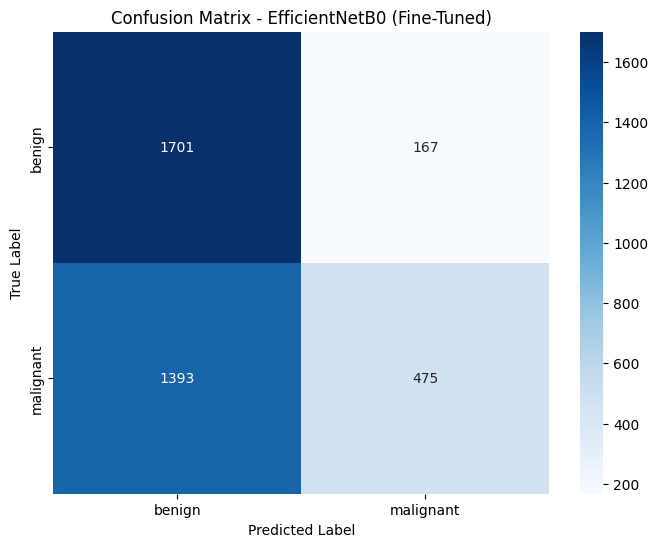

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.title("Confusion Matrix - EfficientNetB0 (Fine-Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


ROC-AUC Score (Fine-Tuned): 0.7113


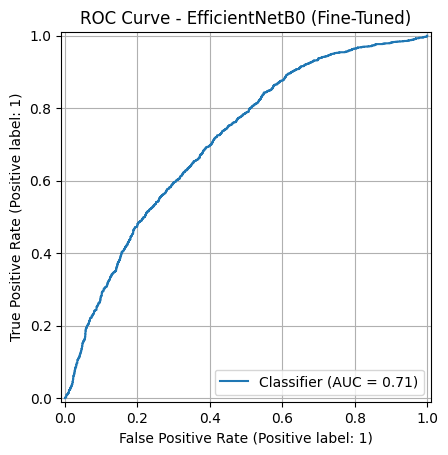

In [39]:
roc_auc_eff_ft = roc_auc_score(y_val, y_pred_eff_ft_prob)
print(f"\nROC-AUC Score (Fine-Tuned): {roc_auc_eff_ft:.4f}")

RocCurveDisplay.from_predictions(y_val, y_pred_eff_ft_prob)
plt.title("ROC Curve - EfficientNetB0 (Fine-Tuned)")
plt.grid(True)
plt.show()

# Results

Model loaded successfully from: /content/drive/MyDrive/dataset_binary_balanced_undersampled/fine_tuned_resnet50_skin_cancer.keras


Saving ISIC_0073227.jpg to ISIC_0073227.jpg
Uploaded image: ISIC_0073227.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


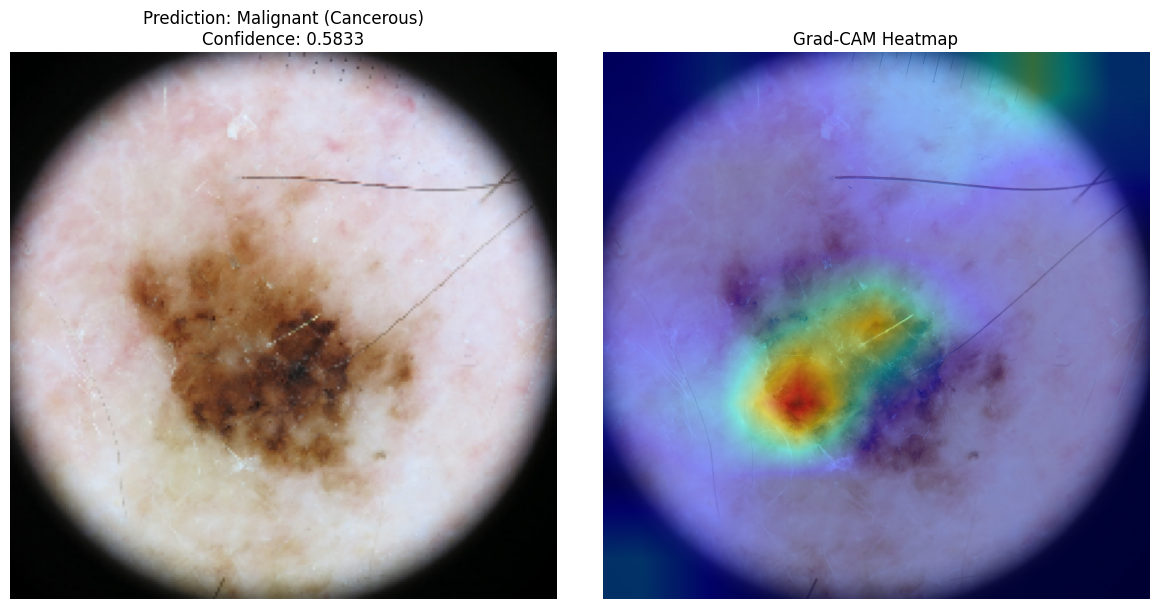

In [40]:
from google.colab import files
model_path = '/content/drive/MyDrive/dataset_binary_balanced_undersampled/fine_tuned_resnet50_skin_cancer.keras'
model = load_model(model_path)
print(f"Model loaded successfully from: {model_path}")

uploaded = files.upload()
image_name = list(uploaded.keys())[0]
print(f"Uploaded image: {image_name}")

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# 5. Prediction function
def predict_image(img_path):
    img_array = preprocess_image(img_path)
    prediction = model.predict(img_array)
    confidence = prediction[0][0]
    if confidence > 0.5:
        result = "Malignant (Cancerous)"
    else:
        result = "Benign (Non-Cancerous)"
    return result, confidence, img_array

# 6. Grad-CAM function
def grad_cam(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)[0]
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# 7. Overlay Grad-CAM on original image
def overlay_heatmap(img_path, heatmap):
    img = cv2.imread(img_path)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
    return superimposed_img

# 8. Run prediction and Grad-CAM
result, confidence, img_array = predict_image(image_name)

# Plotting
img = image.load_img(image_name, target_size=(224, 224))
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {result}\nConfidence: {confidence:.4f}")

last_conv_layer_name = "conv5_block3_out"
heatmap = grad_cam(img_array, model, last_conv_layer_name)
superimposed_img = overlay_heatmap(image_name, heatmap)

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.tight_layout()
plt.show()